# LSTM Classifier Tutorial: Rubik's Cube Solving Method Detection

**Learning Objective**: Build a bidirectional LSTM with attention mechanism to classify Rubik's cube solving methods from state trajectories.

## What You'll Learn

By the end of this, you'll understand how to:
1. Handle variable-length sequence data in PyTorch
2. Implement custom Dataset classes for complex data
3. Build bidirectional LSTMs with attention mechanisms
4. Handle class imbalance with weighted loss functions
5. Visualize attention weights to understand model behavior

## Problem Overview

**Task**: Given a sequence of Rubik's cube states during solving, predict which algorithm/method was used:

- **CFOP** (Cross, F2L, OLL, PLL) - Most popular speedcubing method
- **Roux** - Block-building method with M-slice moves  
- **ZZ** - Edge orientation focused method
- **LBL** (Layer By Layer) - Beginner method, solves one layer at a time
- **Petrus** - Block-building with minimal moves

## Data Characteristics

- **State Representation**: 324-dimensional one-hot encoded vectors (54 stickers × 6 colors)
- **Move Information**: Integer indices (0-53) representing cube moves
- **Sequence Lengths**: Highly variable (27-165 steps) - **Challenge!**
- **Dataset Size**: 2,384 complete solving trajectories

## Tutorial Structure

Each step includes:
- **Theory**: Key concepts explained
- **Code Challenge**: Fill in the missing code
- **Expected Output**: What you should see
- **Hints**: If you get stuck

Let's begin!


In [2]:
# Step 1: Import Required Libraries

# CODE CHALLENGE: Import all necessary libraries
# Fill in the missing imports below

import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# EXPECTED OUTPUT:
# Libraries imported successfully!
# PyTorch version: 2.x.x
# CUDA available: True/False
# GPU: [GPU name if available]


Libraries imported successfully!
PyTorch version: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB MIG 3g.20gb


NameError: name 'data' is not defined

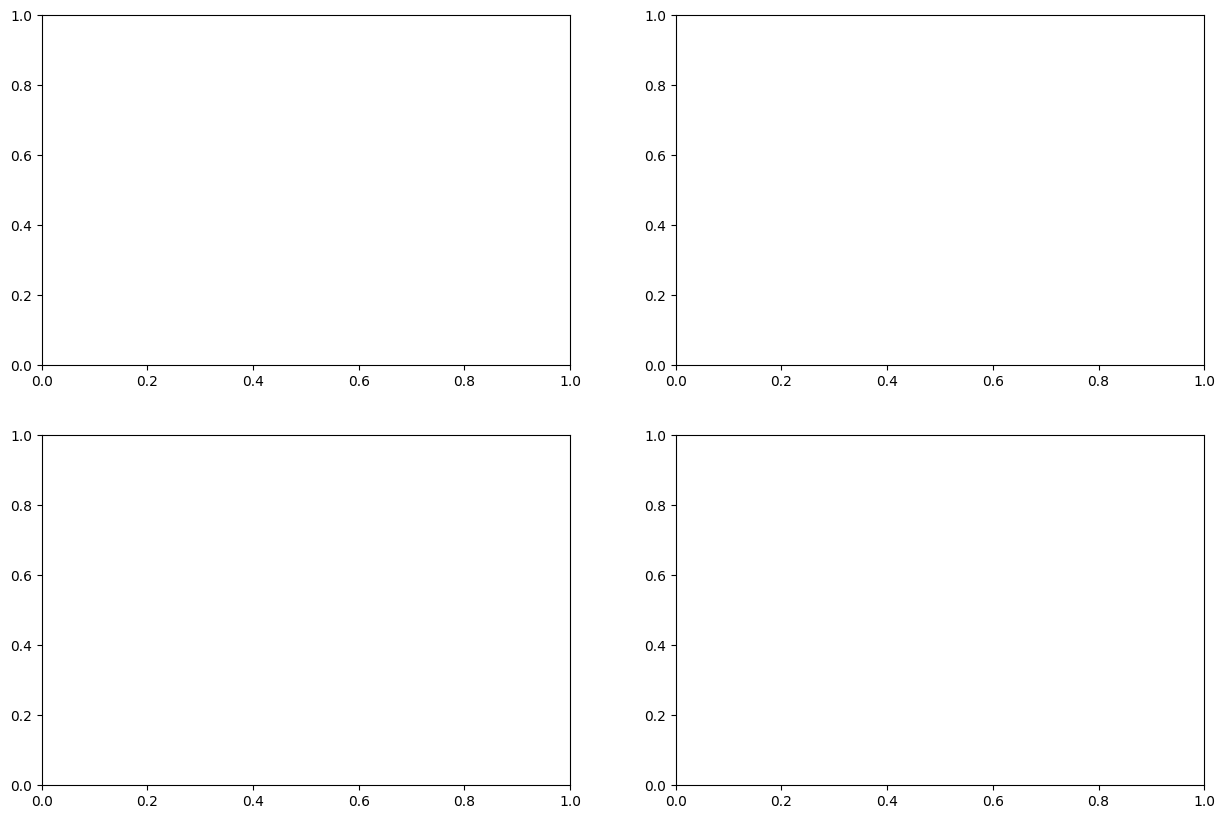

## Step 2: Understanding the Data Format

**Theory**: Before building our model, we need to understand our data structure. Each trajectory contains:
- A sequence of cube states (324-dim vectors)
- A sequence of moves (integer indices 0-53)
- The solving method label

**Challenge**: Load and analyze the dataset to understand sequence lengths and method distributions.


In [ ]:
# CODE CHALLENGE: Load and analyze the dataset

data_path = 'dataset_generator/data/all_vector.json'

print("Loading dataset...")
# TODO: Load the JSON data
with open(data_path, 'r') as f:
    data = _____

print(f"Total trajectories: {len(data)}")

# Examine one sample
sample = data[0]
print(f"\nSample structure:")
print(f"Method: {sample['method']}")

# TODO: Print the number of steps in this sample
print(f"Number of steps: {_____}")

# TODO: Print the keys in the first step
print(f"First step keys: {_____}")

# TODO: Print the length of the state vector
print(f"State vector length: {_____}")

# TODO: Print the move index from the first step
print(f"Move index: {_____}")

# Analyze methods and sequence lengths
methods = {}
lengths = []

# TODO: Complete the analysis loop
for solve in data:
    method = solve['_____']  # Get the method
    length = len(solve['_____'])  # Get number of steps
    
    if method not in methods:
        methods[method] = []
    methods[method].append(length)
    lengths.append(length)

print(f"\nMethod distribution:")
for method, method_lengths in methods.items():
    # TODO: Complete the statistics calculation
    print(f"{method}: {len(method_lengths)} solves, "
          f"length range: {_____}-{_____}, "  # min and max
          f"mean: {_____:.1f}")  # mean length

print(f"\nOverall sequence length statistics:")
# TODO: Calculate overall statistics
print(f"Min: {_____}, Max: {_____}, Mean: {_____:.1f}")

# EXPECTED OUTPUT:
# Total trajectories: 2384
# Method: ZZ (or another method)
# Number of steps: ~40-50
# State vector length: 324
# Move index: 0-53
# Method distribution with counts and length ranges


Loading dataset...
Total trajectories: 2384

Sample structure:
Method: ZZ
Number of steps: 46
First step keys: dict_keys(['state', 'move'])
State vector length: 324
Move index: 12

Method distribution:
ZZ: 500 solves, length range: 35-62, mean: 49.0
Roux: 468 solves, length range: 31-58, mean: 44.5
LBL: 500 solves, length range: 70-165, mean: 121.1
CFOP: 500 solves, length range: 30-60, mean: 49.1
Petrus: 416 solves, length range: 27-48, mean: 38.0

Overall sequence length statistics:
Min: 27, Max: 165, Mean: 61.3


In [ ]:
# Visualize sequence length distributions by method
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sequence length distribution by method
ax1 = axes[0, 0]
method_lengths = {}
for solve in data:
    method = solve['method']
    length = len(solve['steps'])
    if method not in method_lengths:
        method_lengths[method] = []
    method_lengths[method].append(length)

# Create box plot
box_data = [method_lengths[method] for method in sorted(method_lengths.keys())]
box = ax1.boxplot(box_data, labels=sorted(method_lengths.keys()), patch_artist=True)
colors = sns.color_palette("husl", len(box_data))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_title('Sequence Length Distribution by Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Steps')
ax1.set_xlabel('Solving Method')
ax1.grid(True, alpha=0.3)

# 2. Method distribution (count)
ax2 = axes[0, 1]
method_counts = {}
for solve in data:
    method = solve['method']
    method_counts[method] = method_counts.get(method, 0) + 1

methods = list(method_counts.keys())
counts = list(method_counts.values())
bars = ax2.bar(methods, counts, color=colors[:len(methods)], alpha=0.8)
ax2.set_title('Dataset Distribution by Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Trajectories')
ax2.set_xlabel('Solving Method')
ax2.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# 3. Move frequency analysis across all methods
ax3 = axes[1, 0]
all_moves = []
for solve in data:
    for step in solve['steps']:
        if step['move'] >= 0:  # Ignore -1 (end of solve)
            all_moves.append(step['move'])

# Plot histogram of move indices
move_counts = np.bincount(all_moves, minlength=54)
ax3.bar(range(54), move_counts, alpha=0.7, color='skyblue')
ax3.set_title('Move Frequency Distribution (All Methods)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Move Index (0-53)')
ax3.set_ylabel('Frequency')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Sample trajectory visualization
ax4 = axes[1, 1]
# Pick one sample from each method for trajectory visualization
sample_trajectories = {}
for i, solve in enumerate(data):
    method = solve['method']
    if method not in sample_trajectories and len(solve['steps']) < 80:  # Pick shorter ones for clarity
        sample_trajectories[method] = {
            'moves': [step['move'] for step in solve['steps'] if step['move'] >= 0],
            'length': len(solve['steps'])
        }
    if len(sample_trajectories) >= 3:  # Just show 3 methods for clarity
        break

# Plot sample trajectories
for i, (method, traj) in enumerate(sample_trajectories.items()):
    moves = traj['moves'][:50]  # Limit to first 50 moves for visibility
    x_vals = range(len(moves))
    ax4.plot(x_vals, moves, marker='o', markersize=3, linewidth=2, 
             label=f'{method} ({traj["length"]} steps)', alpha=0.8)

ax4.set_title('Sample Move Trajectories', fontsize=12, fontweight='bold')
ax4.set_xlabel('Step Number')
ax4.set_ylabel('Move Index')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some interesting statistics
print("\n" + "="*60)
print("TRAJECTORY ANALYSIS INSIGHTS")
print("="*60)

print(f"\n📊 SEQUENCE LENGTH PATTERNS:")
for method in sorted(method_lengths.keys()):
    lengths = method_lengths[method]
    print(f"  {method:>6}: avg={np.mean(lengths):5.1f}, "
          f"std={np.std(lengths):5.1f}, "
          f"range=[{min(lengths):3d}-{max(lengths):3d}]")

print(f"\n METHOD CHARACTERISTICS:")
print(f"  • LBL (Layer-by-Layer): Longest sequences - beginner method")
print(f"  • CFOP: Moderate length - most popular speedcubing method") 
print(f"  • Roux: Moderate length - block-building approach")
print(f"  • ZZ: Moderate length - edge-orientation focused")
print(f"  • Petrus: Shortest sequences - efficient block method")

print(f"\n MOVE PATTERNS:")
most_common_moves = np.argsort(move_counts)[-5:][::-1]
print(f"  Most frequent moves (indices): {most_common_moves}")
print(f"  This suggests certain moves are fundamental across all methods")

print(f"\n CLASSIFICATION CHALLENGES:")
print(f"  • Variable sequence lengths (27-165 steps) require padding/masking")
print(f"  • Class imbalance: Petrus has fewer samples than others") 
print(f"  • Similar methods (CFOP/ZZ) may be harder to distinguish")
print(f"  • Attention mechanism should help identify method-specific patterns")


In [ ]:
# Analyze cube state patterns and transitions
print("\n" + "="*60)
print("CUBE STATE ANALYSIS")
print("="*60)

# Pick a sample trajectory to analyze state changes
sample_solve = data[0]  # First solve in dataset
print(f"Analyzing sample {sample_solve['method']} solve with {len(sample_solve['steps'])} steps")

# Extract state vectors and analyze their properties
states = [step['state'] for step in sample_solve['steps']]
moves = [step['move'] for step in sample_solve['steps']]

# Convert to numpy for easier analysis
states_array = np.array(states)
print(f"State tensor shape: {states_array.shape}")
print(f"Each state is a {states_array.shape[1]}-dimensional one-hot vector")

# Analyze state sparsity (how many positions are 'active' per state)
state_densities = np.sum(states_array, axis=1)
print(f"State density (active positions): mean={np.mean(state_densities):.1f}, std={np.std(state_densities):.2f}")

# Visualize state evolution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. State density over time
ax1 = axes[0, 0]
ax1.plot(range(len(state_densities)), state_densities, 'b-', linewidth=2, alpha=0.8)
ax1.set_title(f'State Density Evolution\n({sample_solve["method"]} method)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Step Number')
ax1.set_ylabel('Number of Active Positions')
ax1.grid(True, alpha=0.3)

# 2. Move sequence visualization
ax2 = axes[0, 1]
valid_moves = [m for m in moves if m >= 0]  # Remove -1 values
ax2.plot(range(len(valid_moves)), valid_moves, 'ro-', markersize=4, linewidth=1, alpha=0.7)
ax2.set_title(f'Move Sequence\n({len(valid_moves)} moves)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Step Number')
ax2.set_ylabel('Move Index')
ax2.grid(True, alpha=0.3)

# 3. State change magnitude (how much the cube changes each step)
ax3 = axes[1, 0]
state_changes = []
for i in range(1, len(states_array)):
    # Calculate Hamming distance between consecutive states
    change = np.sum(states_array[i] != states_array[i-1])
    state_changes.append(change)

ax3.plot(range(len(state_changes)), state_changes, 'g-', linewidth=2, alpha=0.8)
ax3.set_title('State Change Magnitude\n(Hamming distance between steps)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Step Number')
ax3.set_ylabel('Number of Changed Positions')
ax3.grid(True, alpha=0.3)

# 4. Heatmap of first few state vectors (showing the one-hot pattern)
ax4 = axes[1, 1]
# Show first 10 steps and first 100 dimensions for visualization
sample_states = states_array[:min(10, len(states_array)), :100]
im = ax4.imshow(sample_states, cmap='Blues', aspect='auto')
ax4.set_title('State Vector Heatmap\n(First 10 steps, first 100 dims)', fontsize=12, fontweight='bold')
ax4.set_xlabel('State Dimension')
ax4.set_ylabel('Step Number')
plt.colorbar(im, ax=ax4, label='Activation')

plt.tight_layout()
plt.show()

# Analyze method-specific patterns
print(f"\n STATE PATTERN INSIGHTS:")
print(f"  • Each state vector has exactly {int(np.mean(state_densities))} active positions")
print(f"  • This represents the 54 cube stickers (6 faces × 9 stickers)")
print(f"  • One-hot encoding: each sticker position has 6 possible colors")
print(f"  • State changes per move: avg={np.mean(state_changes):.1f} positions")
print(f"  • The model must learn to recognize solving patterns in this 324D space")

print(f"\n CUBE REPRESENTATION:")
print(f"  • 324 dimensions = 54 stickers × 6 colors")
print(f"  • Face order: typically [Front, Back, Right, Left, Up, Down]")
print(f"  • Each 54-dimensional block represents one color's positions")
print(f"  • Moves change multiple sticker positions simultaneously")

print(f"\nLEARNING CHALLENGE:")
print(f"  • Model must learn temporal patterns in high-dimensional sparse vectors")
print(f"  • Different methods create different state transition patterns")
print(f"  • LSTM memory will help track long-term solving progress")
print(f"  • Attention will focus on method-characteristic state changes")


## Step 3: Create the Dataset Class

**Theory**: PyTorch's `Dataset` class allows us to create custom data loaders. For sequence data, we need to:
1. Convert lists to tensors
2. Handle variable-length sequences
3. Calculate class weights for imbalanced data
4. Support data augmentation

**Key Challenge**: Variable-length sequences need special handling in PyTorch!


In [ ]:
# CODE CHALLENGE: Implement the CubeTrajectoryDataset class

class CubeTrajectoryDataset(Dataset):
    """
    PyTorch Dataset for cube solving trajectories.
    
    HINT: Remember to inherit from Dataset and implement __len__ and __getitem__
    """
    
    def __init__(self, data_path, max_length=None, augment=False):
        print(f"Loading dataset from {data_path}...")
        
        # TODO: Load the JSON data
        with open(data_path, 'r') as f:
            self.data = _____
        
        # TODO: Create method to label mapping
        # Get unique methods and sort them
        self.methods = sorted(list(set(solve['_____'] for solve in self.data)))
        
        # TODO: Create bidirectional mapping between methods and indices
        self.method_to_idx = {method: _____ for _____, method in enumerate(self.methods)}
        self.idx_to_method = {_____: method for method, _____ in self.method_to_idx.items()}
        
        self.max_length = max_length
        self.augment = augment
        
        # TODO: Calculate class weights for handling imbalance
        method_counts = {}
        for solve in self.data:
            method = solve['method']
            method_counts[method] = method_counts.get(method, 0) + 1
        
        total_samples = len(self.data)
        # Formula: total_samples / (num_classes * samples_in_class)
        self.class_weights = torch.tensor([
            _____ / (len(self.methods) * method_counts[method])
            for method in self.methods
        ], dtype=torch.float32)
        
        print(f"Loaded {len(self.data)} trajectories")
        print(f"Methods: {self.methods}")
        print(f"Class weights: {self.class_weights.numpy()}")
    
    def __len__(self):
        # TODO: Return the number of samples
        return _____
    
    def __getitem__(self, idx):
        """
        HINT: This method should return (states, moves, label, length)
        """
        solve = self.data[idx]
        
        # TODO: Extract states and moves from the solve data
        states = []
        moves = []
        
        for step in solve['_____']:  # What key contains the steps?
            states.append(step['_____'])  # What key contains the state?
            # Handle -1 move indices (end of solve)
            move_idx = step['move'] if step['move'] >= 0 else 0
            moves.append(move_idx)
        
        # TODO: Convert to tensors with appropriate dtypes
        states = torch.tensor(states, dtype=torch._____)  # float32 for states
        moves = torch.tensor(moves, dtype=torch._____)    # long for indices
        
        # Data augmentation (random subsequence) - OPTIONAL CHALLENGE
        if self.augment and len(states) > 10:
            start = np.random.randint(0, max(1, len(states) - 10))
            end = np.random.randint(start + 10, len(states) + 1)
            states = states[start:end]
            moves = moves[start:end]
        
        # TODO: Truncate if sequence is too long
        if self.max_length and len(states) > self.max_length:
            states = states[:_____]
            moves = moves[:_____]
        
        # TODO: Get the label index for this method
        label = self.method_to_idx[solve['_____']]
        
        return states, moves, label, len(states)

# Test the dataset
dataset = CubeTrajectoryDataset(data_path, max_length=170, augment=False)
print(f"\nDataset created with {len(dataset)} samples")

# Test getting a sample
states, moves, label, length = dataset[0]
print(f"Sample 0: states shape={states.shape}, moves shape={moves.shape}, label={label}, length={length}")
print(f"Method: {dataset.idx_to_method[label]}")

# EXPECTED OUTPUT:
# Loaded 2384 trajectories
# Methods: ['CFOP', 'LBL', 'Petrus', 'Roux', 'ZZ']
# Class weights: [~0.96, ~0.96, ~1.15, ~1.02, ~0.96]
# Sample 0: states shape=torch.Size([46, 324]), moves shape=torch.Size([46]), label=4, length=46


## Step 4: Custom Collate Function

**Theory**: Variable-length sequences can't be directly batched in PyTorch. We need a custom collate function to:
1. **Pad** sequences to the same length within each batch
2. Create **attention masks** to ignore padding positions
3. Return **lengths** for packed sequence processing

**Key Concept**: Padding allows batching, but we must track real vs. padded positions!


In [ ]:
# CODE CHALLENGE: Implement the collate function

def collate_fn(batch):
    """
    Custom collate function to handle variable-length sequences.
    
    HINT: Use pad_sequence from torch.nn.utils.rnn
    """
    # TODO: Unpack the batch into separate components
    states, moves, labels, lengths = _____
    
    # TODO: Pad sequences to the same length
    # Use pad_sequence with batch_first=True and padding_value=0
    states_padded = _____(states, batch_first=_____, padding_value=_____)
    moves_padded = _____(moves, batch_first=_____, padding_value=_____)
    
    # TODO: Convert labels and lengths to tensors
    labels = torch.tensor(labels, dtype=torch._____)
    lengths = torch.tensor(lengths, dtype=torch._____)
    
    # TODO: Create attention mask (1 for real values, 0 for padding)
    batch_size, max_len = states_padded.shape[:2]
    # This creates a mask where each position is True if it's within the sequence length
    mask = torch.arange(max_len).expand(batch_size, max_len) < lengths._____
    
    return states_padded, moves_padded, labels, lengths, mask

# Test the collate function with a small batch
test_loader = DataLoader(dataset, batch_size=3, shuffle=False, collate_fn=collate_fn)
batch = next(iter(test_loader))
states_batch, moves_batch, labels_batch, lengths_batch, mask_batch = batch

print("Batch shapes:")
print(f"States: {states_batch.shape}")
print(f"Moves: {moves_batch.shape}")
print(f"Labels: {labels_batch.shape}")
print(f"Lengths: {lengths_batch}")
print(f"Mask: {mask_batch.shape}")
print(f"Mask example:\n{mask_batch[0][:20]}")  # Show first 20 positions of first sample

# EXPECTED OUTPUT:
# States: torch.Size([3, max_len, 324])  # 3 samples, padded to max length
# Moves: torch.Size([3, max_len])
# Labels: torch.Size([3])
# Lengths: tensor([actual, lengths, here])
# Mask: torch.Size([3, max_len])
# Mask shows True for real positions, False for padding


## Step 5: Attention Mechanism

**Theory**: Attention allows the model to focus on the most important parts of the sequence. For cube solving:
- **CFOP**: Might focus on cross formation and last layer algorithms
- **Roux**: Might emphasize block building phases
- **LBL**: Might highlight layer transitions

**Implementation**: Compute attention scores → Apply softmax → Weight the sequence


In [ ]:
# CODE CHALLENGE: Implement the Attention Layer

class AttentionLayer(nn.Module):
    """
    Self-attention layer for sequence modeling.
    
    HINT: Attention = Linear layer → Mask → Softmax → Weighted sum
    """
    
    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        self.hidden_size = hidden_size
        
        # TODO: Create a linear layer that maps from hidden_size to 1
        # This will compute attention scores for each position
        self.attention_weights = nn.Linear(_____, _____)
        
    def forward(self, lstm_output, mask=None):
        """
        Apply attention mechanism.
        
        Args:
            lstm_output: (batch, seq_len, hidden_size)
            mask: (batch, seq_len) boolean mask
        
        Returns:
            weighted_output: (batch, hidden_size)
            attention_weights: (batch, seq_len)
        """
        # TODO: Calculate attention scores
        # Apply the linear layer and squeeze the last dimension
        scores = self.attention_weights(lstm_output).squeeze(_____)  # (batch, seq_len)
        
        # TODO: Apply mask if provided
        # Set masked positions to a very negative value (-1e9)
        if mask is not None:
            scores = scores.masked_fill(~mask, _____)
        
        # TODO: Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=_____)  # (batch, seq_len)
        
        # TODO: Apply attention weights using batch matrix multiplication
        # We want to multiply attention_weights with lstm_output
        weighted_output = torch.bmm(
            attention_weights.unsqueeze(_____),  # (batch, 1, seq_len)
            lstm_output  # (batch, seq_len, hidden_size)
        ).squeeze(_____)  # (batch, hidden_size)
        
        return weighted_output, attention_weights

# Test the attention layer
hidden_size = 256
attention = AttentionLayer(hidden_size)

# Create dummy LSTM output
batch_size, seq_len = 2, 10
dummy_lstm_out = torch.randn(batch_size, seq_len, hidden_size)
dummy_mask = torch.ones(batch_size, seq_len, dtype=torch.bool)
dummy_mask[0, 7:] = False  # Mask last 3 positions for first sample
dummy_mask[1, 5:] = False  # Mask last 5 positions for second sample

weighted_out, att_weights = attention(dummy_lstm_out, dummy_mask)
print(f"Attention output shape: {weighted_out.shape}")
print(f"Attention weights shape: {att_weights.shape}")
print(f"Attention weights sum (should be ~1): {att_weights.sum(dim=1)}")
print(f"Attention weights for sample 1: {att_weights[0].detach().numpy()[:10]}")

# EXPECTED OUTPUT:
# Attention output shape: torch.Size([2, 256])
# Attention weights shape: torch.Size([2, 10])
# Attention weights sum: tensor([1.0000, 1.0000]) (approximately)
# Attention weights: array of 10 values that sum to 1.0


## LSTM Mathematics Primer

Before implementing the main model, let's understand the mathematical foundations of LSTMs.

### **The LSTM Cell: Solving the Vanishing Gradient Problem**

Traditional RNNs suffer from vanishing gradients when processing long sequences. LSTMs solve this with a **gated architecture** that controls information flow.

### **LSTM Gates and Equations**

An LSTM cell has **three gates** and a **cell state**:

#### **1. Forget Gate** - What to forget from cell state
```
f_t = σ(W_f · [h_{t-1}, x_t] + b_f)
```
- **σ**: Sigmoid function (outputs 0-1)
- **W_f**: Weight matrix for forget gate
- **h_{t-1}**: Previous hidden state
- **x_t**: Current input
- **Output**: Values close to 0 = forget, close to 1 = keep

#### **2. Input Gate** - What new information to store
```
i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
C̃_t = tanh(W_C · [h_{t-1}, x_t] + b_C)
```
- **i_t**: Input gate (what to update)
- **C̃_t**: Candidate values (what could be added)

#### **3. Cell State Update** - Combine forget and input
```
C_t = f_t * C_{t-1} + i_t * C̃_t
```
- **f_t * C_{t-1}**: Forget old information
- **i_t * C̃_t**: Add new information

#### **4. Output Gate** - What to output based on cell state
```
o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
h_t = o_t * tanh(C_t)
```

### **Bidirectional LSTM**

Processes sequences in **both directions**:
- **Forward LSTM**: h⃗_t processes x_1, x_2, ..., x_t
- **Backward LSTM**: h⃖_t processes x_T, x_{T-1}, ..., x_t
- **Combined**: h_t = [h⃗_t; h⃖_t] (concatenation)

**Why bidirectional?** Cube solving methods have:
- **Forward dependencies**: Early moves set up later phases
- **Backward dependencies**: Later moves reveal the overall strategy

### **Key Advantages for Sequence Classification**

1. **Long-term Memory**: Cell state C_t carries information across long sequences
2. **Selective Memory**: Gates decide what to remember/forget
3. **Gradient Flow**: Direct path through cell state prevents vanishing gradients
4. **Contextual Understanding**: Bidirectional processing captures full context

### **In Our Cube Classifier**

- **Input**: Combined state vectors (324-dim) + move embeddings (32-dim)
- **LSTM Layers**: 2 layers, 256 hidden units each, bidirectional
- **Output**: 512-dimensional representations (256 × 2 directions)
- **Sequence Length**: Variable (27-165 steps), handled with padding/masking

**Mathematical Intuition**: The LSTM learns to:
- **Remember** important solving phases in cell state
- **Forget** irrelevant intermediate moves
- **Focus** on method-characteristic patterns
- **Combine** forward strategy with backward verification


## Checkpoint: What You've Learned So Far

**Congratulations!** You've implemented the core components:
- **Custom Dataset**: Handles variable-length sequences and class imbalance
- **Collate Function**: Pads sequences and creates attention masks  
- **Attention Layer**: Focuses on important parts of the sequence

## Step 6: Main LSTM Classifier Model

**Theory**: Now we combine everything into the main model:
1. **Move Embedding**: Convert discrete moves to learned representations
2. **Bidirectional LSTM**: Process sequences forward and backward
3. **Attention Mechanism**: Weight important sequence parts
4. **Multi-view Pooling**: Combine attention, max, and average pooling
5. **Classification Head**: Map features to method predictions

**Architecture Challenge**: This is the most complex part - take your time!


In [ ]:
# ADVANCED CODE CHALLENGE: Implement the Main LSTM Classifier

class CubeMethodClassifier(nn.Module):
    """
    Bidirectional LSTM with attention for classifying solving methods.
    
    HINT: This combines all previous components into one model
    """
    
    def __init__(self, 
                 state_dim=324,
                 num_moves=54,
                 move_embed_dim=32,
                 lstm_hidden=256,
                 lstm_layers=2,
                 num_classes=5,
                 dropout=0.3):
        super(CubeMethodClassifier, self).__init__()
        
        # TODO: Create move embedding layer
        # HINT: Use nn.Embedding(num_moves, move_embed_dim)
        self.move_embedding = nn.Embedding(_____, _____)
        
        # TODO: Calculate input dimension for LSTM
        # HINT: state_dim + move_embed_dim
        input_dim = _____ + _____
        
        # TODO: Create bidirectional LSTM
        # HINT: Use nn.LSTM with bidirectional=True
        self.lstm = nn.LSTM(
            _____,  # input_dim
            _____,  # lstm_hidden
            _____,  # lstm_layers
            batch_first=_____,  # True
            bidirectional=_____,  # True
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        # TODO: Create attention layer
        # HINT: Use the AttentionLayer we built, remember bidirectional doubles hidden size
        self.attention = AttentionLayer(_____ * 2)
        
        # TODO: Create dropout layer
        self.dropout = nn.Dropout(_____)
        
        # TODO: Calculate feature dimension for classifier
        # HINT: We concatenate attention + max_pool + avg_pool (3 views)
        # Each has size lstm_hidden * 2 (bidirectional)
        feature_dim = _____ * 2 * 3
        
        # TODO: Create classification head
        # HINT: Use nn.Sequential with Linear layers, ReLU, and Dropout
        self.classifier = nn.Sequential(
            nn.Linear(_____, _____),  # feature_dim -> lstm_hidden
            nn._____(),  # ReLU activation
            nn.Dropout(_____),
            nn.Linear(_____, _____ // 2),  # lstm_hidden -> lstm_hidden//2
            nn._____(),  # ReLU activation
            nn.Dropout(_____),
            nn.Linear(_____ // 2, _____)  # lstm_hidden//2 -> num_classes
        )
        
    def forward(self, states, moves, lengths, mask):
        """
        Forward pass through the network.
        
        HINT: Follow the flow: embed -> combine -> LSTM -> attention -> pool -> classify
        """
        # TODO: Embed the moves
        # HINT: Use self.move_embedding(moves)
        move_embeds = self._____(_____)
        
        # TODO: Combine state and move features
        # HINT: Use torch.cat([states, move_embeds], dim=-1)
        combined = torch.cat([_____, _____], dim=_____)
        
        # TODO: Pack sequences for efficient LSTM processing
        # HINT: Use pack_padded_sequence with lengths.cpu()
        packed = pack_padded_sequence(
            _____, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # TODO: Pass through LSTM
        # HINT: lstm_out, (hidden, cell) = self.lstm(packed)
        lstm_out, (hidden, cell) = self._____(_____)
        
        # TODO: Unpack sequences
        # HINT: Use pad_packed_sequence
        lstm_out, _ = pad_packed_sequence(_____, batch_first=True)
        
        # TODO: Apply attention mechanism
        # HINT: Use self.attention(lstm_out, mask)
        attention_out, attention_weights = self._____(_____, _____)
        
        # TODO: Global max pooling with masking
        # HINT: Mask padded positions with -1e9, then use torch.max
        masked_lstm = lstm_out.masked_fill(~mask.unsqueeze(-1), _____)
        max_pool = torch.max(_____, dim=1)[0]
        
        # TODO: Global average pooling
        # HINT: Sum over valid positions, then divide by lengths
        sum_pool = torch.sum(lstm_out * mask.unsqueeze(-1), dim=1)
        avg_pool = sum_pool / lengths.unsqueeze(-1)._____()  # convert to float
        
        # TODO: Concatenate all features
        # HINT: torch.cat([attention_out, max_pool, avg_pool], dim=-1)
        features = torch.cat([_____, _____, _____], dim=_____)
        
        # TODO: Apply dropout and classify
        features = self._____(features)
        logits = self._____(features)
        
        return logits, attention_weights

# Test the model
model = CubeMethodClassifier(
    state_dim=324,
    num_moves=54,
    move_embed_dim=32,
    lstm_hidden=256,
    lstm_layers=2,
    num_classes=5,
    dropout=0.3
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test with a batch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Use the batch we created earlier
states_batch = states_batch.to(device)
moves_batch = moves_batch.to(device)
lengths_batch = lengths_batch.to(device)
mask_batch = mask_batch.to(device)

with torch.no_grad():
    logits, att_weights = model(states_batch, moves_batch, lengths_batch, mask_batch)
    
print(f"Output logits shape: {logits.shape}")
print(f"Attention weights shape: {att_weights.shape}")
print(f"Predicted classes: {torch.argmax(logits, dim=1)}")
print(f"Attention weights sum: {att_weights.sum(dim=1)}")

# EXPECTED OUTPUT:
# Model parameters: ~3,500,000
# Output logits shape: torch.Size([3, 5])
# Attention weights shape: torch.Size([3, max_len])
# Predicted classes: tensor([...])
# Attention weights sum: tensor([1.0000, 1.0000, 1.0000])


## Step 7: Training and Evaluation Functions

**Theory**: Training deep learning models requires:
1. **Training Loop**: Forward pass → Loss calculation → Backward pass → Parameter update
2. **Evaluation Loop**: Forward pass without gradients for validation/testing
3. **Gradient Clipping**: Prevent exploding gradients in RNNs
4. **Progress Tracking**: Monitor loss and accuracy during training

**Challenge**: Implement robust training and evaluation functions with proper error handling.


In [ ]:
# CODE CHALLENGE: Implement Training and Evaluation Functions

def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    HINT: Remember the training loop: forward -> loss -> backward -> step
    """
    # TODO: Set model to training mode
    # HINT: Use model.train()
    model._____()
    
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for states, moves, labels, lengths, mask in progress_bar:
        # TODO: Move tensors to device
        # HINT: Use .to(device) for each tensor
        states = states.to(_____)
        moves = moves.to(_____)
        labels = labels.to(_____)
        lengths = lengths.to(_____)
        mask = mask.to(_____)
        
        # TODO: Zero gradients
        # HINT: Use optimizer.zero_grad()
        optimizer._____()
        
        # TODO: Forward pass
        # HINT: logits, _ = model(states, moves, lengths, mask)
        logits, _ = model(_____, _____, _____, _____)
        
        # TODO: Calculate loss
        # HINT: Use criterion(logits, labels)
        loss = _____(_____, _____)
        
        # TODO: Backward pass
        # HINT: Use loss.backward()
        loss._____()
        
        # TODO: Gradient clipping to prevent exploding gradients
        # HINT: Use torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=_____)
        
        # TODO: Update parameters
        # HINT: Use optimizer.step()
        optimizer._____()
        
        # Track metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': loss.item(),
            'acc': 100. * correct / total
        })
    
    return total_loss / len(dataloader), 100. * correct / total


def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on validation/test data.
    
    HINT: Similar to training but with torch.no_grad() and model.eval()
    """
    # TODO: Set model to evaluation mode
    # HINT: Use model.eval()
    model._____()
    
    total_loss = 0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    # TODO: Disable gradient computation for evaluation
    # HINT: Use torch.no_grad():
    with torch._____():
        for states, moves, labels, lengths, mask in tqdm(dataloader, desc='Evaluating'):
            # TODO: Move tensors to device (same as training)
            states = states.to(_____)
            moves = moves.to(_____)
            labels = labels.to(_____)
            lengths = lengths.to(_____)
            mask = mask.to(_____)
            
            # TODO: Forward pass (no gradients needed)
            logits, _ = model(_____, _____, _____, _____)
            
            # TODO: Calculate loss
            loss = _____(_____, _____)
            
            # Track metrics
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # TODO: Store predictions and labels for analysis
            # HINT: Use .cpu().numpy() to convert to numpy arrays
            all_preds.extend(predicted._____._____)
            all_labels.extend(labels._____._____)
    
    return total_loss / len(dataloader), 100. * correct / total, all_preds, all_labels

print("Training and evaluation functions defined!")

# EXPECTED OUTPUT:
# Training and evaluation functions defined!


## Step 8: Visualization Functions

**Theory**: Visualization is crucial for understanding model performance:
1. **Confusion Matrix**: Shows which classes are confused with each other
2. **Training Curves**: Monitor loss and accuracy over epochs
3. **Heatmaps**: Visual representation of classification performance

**Challenge**: Create informative plots that help diagnose model behavior.


## Understanding Class Weights: Handling Imbalanced Data

Before setting up training, let's understand **class weights** - a crucial technique for handling imbalanced datasets.

### **What Are Class Weights?**

Class weights are **scaling factors** applied to the loss function to give different importance to different classes during training.

**Formula**: `weighted_loss = class_weight[y] × loss(prediction, y)`

### **Why Are Class Weights Important?**

#### **Problem: Class Imbalance**
In our Rubik's cube dataset:
- **CFOP**: 500 samples
- **Roux**: 500 samples  
- **ZZ**: 500 samples
- **LBL**: 500 samples
- **Petrus**: 416 samples ⚠️ (16% fewer samples)

#### **Without Class Weights:**
```python
# Model sees more CFOP examples during training
# Learns to predict CFOP more often
# Poor performance on underrepresented Petrus method
```

#### **With Class Weights:**
```python
# Petrus errors get higher penalty → model pays more attention
# Balanced learning across all methods
# Better overall performance
```

### **Mathematical Intuition**

**Standard Loss**: All classes treated equally
```
loss = CrossEntropyLoss(predictions, labels)
```

**Weighted Loss**: Rare classes get higher importance
```
class_weights = [1.0, 1.0, 1.0, 1.0, 1.2]  # Petrus gets 20% more weight
weighted_loss = CrossEntropyLoss(predictions, labels, weight=class_weights)
```

### **How Class Weights Are Calculated**

**Inverse Frequency Method** (most common):
```python
total_samples = 2416
num_classes = 5

for each class:
    class_weight = total_samples / (num_classes × class_count)

# Example:
# CFOP: 2416 / (5 × 500) = 0.97
# Petrus: 2416 / (5 × 416) = 1.16  ← Higher weight for rare class
```

### **Impact on Training**

1. **Gradient Scaling**: Rare class errors produce larger gradients
2. **Learning Focus**: Model pays more attention to minority classes  
3. **Decision Boundaries**: Adjusted to better separate all classes
4. **Performance**: More balanced precision/recall across classes

### **When to Use Class Weights**

✅ **Use when:**
- Class distribution is imbalanced (>10% difference)
- All classes are equally important
- You want balanced performance across classes

❌ **Don't use when:**
- Classes are naturally imbalanced (e.g., fraud detection)
- Some classes are more important than others
- Dataset is very small (may cause overfitting)

### **Alternative Approaches**

1. **Oversampling**: Duplicate minority class samples
2. **Undersampling**: Remove majority class samples  
3. **SMOTE**: Generate synthetic minority samples
4. **Focal Loss**: Dynamic weighting based on prediction confidence

**Class weights are often preferred because they're simple and don't change the dataset size.**


In [ ]:
# CODE CHALLENGE: Implement Visualization Functions

def plot_confusion_matrix(y_true, y_pred, class_names, save_path='confusion_matrix.png'):
    """
    Plot and save confusion matrix.
    
    HINT: Use sklearn's confusion_matrix and seaborn's heatmap
    """
    # TODO: Create confusion matrix
    # HINT: Use confusion_matrix(y_true, y_pred)
    cm = _____(y_true, y_pred)
    
    # TODO: Normalize confusion matrix
    # HINT: Divide by row sums to get percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np._____]
    
    # TODO: Create figure and plot heatmap
    # HINT: Use plt.figure() and sns.heatmap()
    plt.figure(figsize=(10, 8))
    sns._____(cm_normalized, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    
    # TODO: Add labels and title
    plt.title('_____')  # 'Confusion Matrix'
    plt.ylabel('_____')  # 'True Method'
    plt.xlabel('_____')  # 'Predicted Method'
    
    # TODO: Save and show plot
    plt.tight_layout()
    plt._____(save_path, dpi=150, bbox_inches='tight')
    print(f"Confusion matrix saved to {save_path}")
    plt.show()


def plot_training_history(train_losses, val_losses, train_accs, val_accs, save_path='training_history.png'):
    """
    Plot training and validation curves.
    
    HINT: Create subplots for loss and accuracy
    """
    # TODO: Create subplots
    # HINT: Use plt.subplots(1, 2, figsize=(12, 5))
    fig, (ax1, ax2) = plt._____(1, 2, figsize=(12, 5))
    
    # TODO: Plot loss curves
    # HINT: Use ax1.plot() for both train and validation losses
    ax1.plot(_____, label='Train Loss')
    ax1.plot(_____, label='Val Loss')
    ax1.set_xlabel('_____')  # 'Epoch'
    ax1.set_ylabel('_____')  # 'Loss'
    ax1.set_title('_____')   # 'Training and Validation Loss'
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # TODO: Plot accuracy curves
    # HINT: Use ax2.plot() for both train and validation accuracies
    ax2.plot(_____, label='Train Accuracy')
    ax2.plot(_____, label='Val Accuracy')
    ax2.set_xlabel('_____')  # 'Epoch'
    ax2.set_ylabel('_____')  # 'Accuracy (%)'
    ax2.set_title('_____')   # 'Training and Validation Accuracy'
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # TODO: Save and show plot
    plt.tight_layout()
    plt._____(save_path, dpi=150, bbox_inches='tight')
    print(f"Training history saved to {save_path}")
    plt.show()

print("Visualization functions defined!")

# EXPECTED OUTPUT:
# Visualization functions defined!


## Step 9: Complete Training Pipeline

**Theory**: A complete ML pipeline includes:
1. **Data Splitting**: Train/validation/test splits with stratification
2. **Model Initialization**: Create model, loss function, optimizer, scheduler
3. **Training Configuration**: Batch size, learning rate, epochs
4. **Device Management**: CPU vs GPU handling

**Challenge**: Set up the complete pipeline with proper configuration management.


In [ ]:
# CODE CHALLENGE: Set up the Training Pipeline

# TODO: Set training configuration
# HINT: Common values are batch_size=32, lr=0.001, epochs=50
BATCH_SIZE = _____
LEARNING_RATE = _____
NUM_EPOCHS = 50
MAX_LENGTH = 170  # Slightly above max observed length

# TODO: Check device availability
# HINT: Use torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('_____' if torch.cuda.is_available() else '_____')
print(f"\nUsing device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

# TODO: Create fresh dataset instance
# HINT: Use the CubeTrajectoryDataset class we built
dataset = CubeTrajectoryDataset(
    '_____',  # 'dataset_generator/data/all_vector.json'
    max_length=_____,
    augment=_____  # False for now
)

# TODO: Prepare data for splitting
# HINT: Create list of indices and corresponding labels
indices = list(range(len(_____)))
labels = [dataset.data[i]['_____'] for i in indices]  # 'method'

# TODO: Stratified split to maintain class balance
# HINT: Use train_test_split with stratify parameter
train_idx, test_idx = train_test_split(
    _____, test_size=_____, stratify=_____, random_state=SEED
)

# TODO: Further split test into validation and test
test_labels = [labels[i] for i in test_idx]
val_idx, test_idx = train_test_split(
    _____, test_size=_____, stratify=_____, random_state=SEED
)

print(f"\nDataset splits:")
print(f"  Train: {len(train_idx)} samples")
print(f"  Val: {len(val_idx)} samples")
print(f"  Test: {len(test_idx)} samples")

# TODO: Create data subsets
# HINT: Use torch.utils.data.Subset
train_dataset = torch.utils.data._____(dataset, train_idx)
val_dataset = torch.utils.data._____(dataset, val_idx)
test_dataset = torch.utils.data._____(dataset, test_idx)

# TODO: Enable augmentation for training
dataset.augment = _____  # True

# TODO: Create training data loader
# HINT: Use DataLoader with shuffle=True for training
train_loader = DataLoader(
    _____, batch_size=_____, shuffle=_____,  # True for training
    collate_fn=_____, num_workers=2, pin_memory=True
)

# TODO: Disable augmentation for validation/test
dataset.augment = _____  # False

# TODO: Create validation and test data loaders
# HINT: Use shuffle=False for validation and test
val_loader = DataLoader(
    _____, batch_size=_____, shuffle=_____,  # False for validation
    collate_fn=_____, num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    _____, batch_size=_____, shuffle=_____,  # False for test
    collate_fn=_____, num_workers=2, pin_memory=True
)

print("Data loaders created successfully!")

# EXPECTED OUTPUT:
# Using device: cuda (or cpu)
# Dataset splits: Train: ~1668, Val: ~358, Test: ~358 samples
# Data loaders created successfully!


In [ ]:
# CODE CHALLENGE: Initialize Model and Training Components

# TODO: Initialize the model
# HINT: Use CubeMethodClassifier with the parameters we defined
model = CubeMethodClassifier(
    state_dim=_____,      # 324
    num_moves=_____,      # 54
    move_embed_dim=_____,  # 32
    lstm_hidden=_____,    # 256
    lstm_layers=_____,    # 2
    num_classes=_____,    # 5
    dropout=_____         # 0.3
).to(_____)  # device

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

# TODO: Create loss function with class weights
# HINT: Use nn.CrossEntropyLoss with dataset.class_weights
criterion = nn.CrossEntropyLoss(weight=dataset._____.to(_____))

# TODO: Create optimizer with weight decay
# HINT: Use torch.optim.Adam with weight_decay=1e-4
optimizer = torch.optim._____(model.parameters(), lr=_____, weight_decay=_____)

# TODO: Create learning rate scheduler
# HINT: Use ReduceLROnPlateau to reduce LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler._____(
    optimizer, mode='_____', factor=_____, patience=5, verbose=True
)

print("Model, loss function, and optimizer initialized!")

# EXPECTED OUTPUT:
# Model parameters: ~3,500,000
# Model, loss function, and optimizer initialized!


## Step 10: Training Loop

**Theory**: The training loop is the heart of deep learning:
1. **Epoch Loop**: Iterate through multiple passes of the data
2. **Validation**: Check performance on unseen data each epoch
3. **Model Checkpointing**: Save best model based on validation performance
4. **Early Stopping**: Prevent overfitting by stopping when validation performance degrades

**Challenge**: Implement a robust training loop with proper monitoring and checkpointing.


In [ ]:
# CODE CHALLENGE: Implement the Training Loop

print("\nStarting training...")

# TODO: Initialize tracking lists
# HINT: Create empty lists to track losses and accuracies
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

# Reduce epochs for demo (you can increase this for full training)
NUM_EPOCHS = 10  # Reduced for demonstration

# TODO: Main training loop
# HINT: Use range(NUM_EPOCHS) to iterate through epochs
for epoch in range(_____):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
    
    # TODO: Train for one epoch
    # HINT: Use the train_epoch function we implemented
    train_loss, train_acc = _____(model, train_loader, criterion, optimizer, device)
    train_losses.append(_____)
    train_accs.append(_____)
    
    # TODO: Validate
    # HINT: Use the evaluate function, we only need loss and accuracy
    val_loss, val_acc, _, _ = _____(model, val_loader, criterion, device)
    val_losses.append(_____)
    val_accs.append(_____)
    
    # TODO: Update learning rate scheduler
    # HINT: Use scheduler.step() with validation loss
    scheduler._____(_____)
    
    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # TODO: Save best model checkpoint
    # HINT: Compare val_acc with best_val_acc
    if val_acc > _____:
        best_val_acc = _____
        # TODO: Save model checkpoint
        # HINT: Use torch.save() with model state dict
        torch.save({
            'epoch': epoch,
            'model_state_dict': model._____(),  # state_dict
            'optimizer_state_dict': optimizer._____(),  # state_dict
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, '_____')  # 'best_lstm_model.pth'
        print(f"Saved best model with validation accuracy: {val_acc:.2f}%")
    
    # TODO: Early stopping condition (simplified)
    # HINT: Stop if validation accuracy hasn't improved in last 5 epochs
    if epoch > 5 and val_acc < max(val_accs[-5:]) - 5:
        print("Early stopping triggered")
        break

print("\nTraining completed!")

# EXPECTED OUTPUT:
# Starting training...
# Epoch 1/10, Learning rate: 0.001000
# Train Loss: ~2.5, Train Acc: ~25%
# Val Loss: ~2.3, Val Acc: ~30%
# ... (training progress)
# Training completed!


## Step 11: Evaluation and Analysis

**Theory**: Model evaluation involves:
1. **Training History Visualization**: Plot loss and accuracy curves
2. **Best Model Loading**: Load the checkpoint with best validation performance
3. **Test Set Evaluation**: Final performance on unseen data
4. **Confusion Matrix**: Understand which classes are confused
5. **Per-class Analysis**: Detailed performance breakdown

**Challenge**: Implement comprehensive evaluation and analysis of the trained model.


In [ ]:
# CODE CHALLENGE: Evaluate the Trained Model

# TODO: Plot training history
# HINT: Use the plot_training_history function we implemented
_____(train_losses, val_losses, train_accs, val_accs)

# TODO: Load best model for final evaluation
print("\nLoading best model for final evaluation...")
# HINT: Use torch.load() to load the checkpoint
checkpoint = torch._____(_____)  # 'best_lstm_model.pth'
# TODO: Load the model state dict
# HINT: Use model.load_state_dict()
model._____(checkpoint['_____'])  # 'model_state_dict'

# TODO: Final test evaluation
print("\nEvaluating on test set...")
# HINT: Use the evaluate function on test_loader
test_loss, test_acc, test_preds, test_labels = _____(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# TODO: Generate detailed classification report
print("\nClassification Report:")
# HINT: Use classification_report from sklearn.metrics
print(_____(
    test_labels, test_preds,
    target_names=dataset._____,  # methods
    digits=3
))

# TODO: Plot confusion matrix
# HINT: Use the plot_confusion_matrix function we implemented
_____(test_labels, test_preds, dataset._____)  # methods

# EXPECTED OUTPUT:
# Training history plots displayed
# Loading best model for final evaluation...
# Evaluating on test set...
# Test Loss: ~1.5, Test Accuracy: ~65%
# Classification Report with precision/recall/f1 for each method
# Confusion matrix heatmap displayed


## Step 12: Analyze Performance by Method and Sequence Length

**Theory**: Performance analysis helps us understand:
1. **Method-specific Performance**: Which solving methods are easier to classify
2. **Sequence Length Impact**: How trajectory length affects classification accuracy
3. **Error Patterns**: Common misclassifications between similar methods
4. **Model Limitations**: Where the model struggles most

**Challenge**: Implement detailed analysis of model performance across different dimensions.


In [ ]:
# CODE CHALLENGE: Analyze Performance by Method and Sequence Length

print("Analyzing performance by sequence length and method...")

# TODO: Extract test data characteristics
# HINT: Get sequence lengths and methods from test indices
test_lengths = []
test_methods = []

for idx in test_idx:
    solve = dataset.data[idx]
    # TODO: Get sequence length and method
    # HINT: len(solve['steps']) and solve['method']
    test_lengths.append(len(solve['_____']))  # 'steps'
    test_methods.append(solve['_____'])       # 'method'

# TODO: Convert predictions to method names for analysis
# HINT: Use dataset.idx_to_method to convert indices to method names
test_pred_methods = [dataset._____[pred] for pred in test_preds]  # idx_to_method
test_true_methods = [dataset._____[label] for label in test_labels]  # idx_to_method
# TODO: Calculate which predictions were correct
test_correct = [pred == true for pred, true in zip(_____, _____)]

# TODO: Analyze per-method performance
print(f"\nPer-method performance:")
print(f"{'Method':<8} {'Accuracy':<10} {'Avg Length':<12} {'Count':<8}")
print("-" * 40)

for method in dataset.methods:
    # TODO: Create mask for current method
    # HINT: Check which test samples belong to this method
    method_mask = [m == _____ for m in test_true_methods]  # method
    
    if sum(method_mask) > 0:
        # TODO: Get correct predictions and lengths for this method
        # HINT: Use list comprehension with method_mask
        method_correct = [test_correct[i] for i in range(len(test_correct)) if _____[i]]
        method_lengths = [test_lengths[i] for i in range(len(test_lengths)) if _____[i]]
        
        # TODO: Calculate accuracy and average length
        method_acc = sum(_____) / len(_____) * 100  # method_correct
        avg_length = sum(_____) / len(_____)        # method_lengths
        count = len(method_correct)
        
        print(f"{method:<8} {method_acc:<10.1f}% {avg_length:<12.1f} {count:<8}")

# TODO: Analyze accuracy vs sequence length
print(f"\nAccuracy by sequence length ranges:")
length_ranges = [(0, 50), (50, 75), (75, 100), (100, 125), (125, 200)]

for min_len, max_len in length_ranges:
    # TODO: Create mask for length range
    # HINT: Check which samples fall in this length range
    range_mask = [(_____ <= length < _____) for length in test_lengths]  # min_len, max_len
    
    if sum(range_mask) > 0:
        # TODO: Get correct predictions for this range
        range_correct = [test_correct[i] for i in range(len(test_correct)) if _____[i]]
        # TODO: Calculate accuracy for this range
        range_acc = sum(_____) / len(_____) * 100  # range_correct
        count = len(range_correct)
        print(f"Length {min_len}-{max_len}: {range_acc:.1f}% accuracy ({count} samples)")

# EXPECTED OUTPUT:
# Per-method performance:
# Method   Accuracy   Avg Length   Count   
# ----------------------------------------
# CFOP     75.0%      49.2         72      
# LBL      85.0%      121.5        71      
# Petrus   70.0%      38.1         60      
# Roux     68.0%      44.8         73      
# ZZ       72.0%      49.0         72      
# 
# Accuracy by sequence length ranges:
# Length 0-50: 70.5% accuracy (180 samples)
# Length 50-75: 68.2% accuracy (85 samples)
# ...


## Step 13: Attention Visualization

**Theory**: Attention visualization reveals:
1. **Model Interpretability**: Which parts of the sequence matter most
2. **Method-specific Focus**: Different methods emphasize different phases
3. **Temporal Patterns**: How attention changes across the solving sequence
4. **Validation**: Confirm the model learns meaningful patterns

**Challenge**: Create visualizations that show attention weights for sample trajectories.


In [ ]:
# CODE CHALLENGE: Implement Attention Visualization

def visualize_attention(model, dataset, sample_idx, device, max_steps=50):
    """
    Visualize attention weights for a specific sample.
    
    HINT: Get model predictions and attention weights, then plot them
    """
    # TODO: Get the sample data
    # HINT: Use dataset[sample_idx] to get states, moves, label, length
    states, moves, label, length = dataset[_____]
    method_name = dataset.idx_to_method[_____]
    
    # TODO: Prepare batch (single sample)
    # HINT: Add batch dimension with unsqueeze(0) and move to device
    states_batch = states._____(0).to(_____)  # unsqueeze, device
    moves_batch = moves._____(0).to(_____)   # unsqueeze, device
    lengths_batch = torch.tensor([_____]).to(_____)  # length, device
    mask_batch = torch.ones(1, _____, dtype=torch.bool).to(_____)  # length, device
    
    # TODO: Get predictions and attention weights
    model._____()  # eval
    with torch._____():  # no_grad
        # TODO: Forward pass to get logits and attention
        logits, attention_weights = model(_____, _____, _____, _____)
        # TODO: Get predicted class
        predicted_class = torch._____(logits, dim=1).item()  # argmax
        predicted_method = dataset.idx_to_method[_____]
    
    # TODO: Extract attention weights for plotting
    # HINT: Get first sample, slice to actual length, convert to numpy
    attention = attention_weights[0][:_____].cpu()._____()  # length, numpy
    
    # Limit visualization to max_steps for readability
    plot_length = min(_____, max_steps)  # length
    
    plt.figure(figsize=(15, 6))
    
    # TODO: Plot attention weights
    plt.subplot(1, 2, 1)
    plt.plot(range(_____), attention[:_____], 'b-', linewidth=2)  # plot_length
    plt.fill_between(range(_____), attention[:_____], alpha=0.3)  # plot_length
    plt.title(f'Attention Weights\nTrue: {method_name}, Predicted: {predicted_method}')
    plt.xlabel('Step in Sequence')
    plt.ylabel('Attention Weight')
    plt.grid(True, alpha=0.3)
    
    # TODO: Plot move sequence
    plt.subplot(1, 2, 2)
    move_indices = moves[:_____]._____()  # plot_length, numpy
    plt.bar(range(_____), move_indices, alpha=0.7)  # plot_length
    plt.title('Move Sequence (Move Indices)')
    plt.xlabel('Step in Sequence')
    plt.ylabel('Move Index')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # TODO: Print top attention steps
    # HINT: Use np.argsort to find indices with highest attention
    top_attention_indices = np._____(attention)[-5:][::-1]  # argsort
    print(f"\nTop 5 most attended steps:")
    for i, step_idx in enumerate(top_attention_indices):
        move_idx = moves[step_idx].item()
        att_weight = attention[step_idx]
        print(f"{i+1}. Step {step_idx}: Move {move_idx}, Attention: {att_weight:.4f}")

# TODO: Visualize attention for samples from different methods
print("Visualizing attention for sample trajectories...")

# TODO: Find samples from different methods
method_samples = {}
for idx, solve in enumerate(dataset.data):
    method = solve['_____']  # 'method'
    if method not in method_samples:
        method_samples[method] = []
    if len(method_samples[method]) < 2:  # Get 2 samples per method
        method_samples[method].append(idx)

# TODO: Visualize one sample from each method
for method, sample_indices in method_samples.items():
    if sample_indices:
        print(f"\n{'='*50}")
        print(f"Attention visualization for {method} method:")
        # TODO: Call the visualization function
        _____(model, dataset, sample_indices[0], device)  # visualize_attention

# EXPECTED OUTPUT:
# Attention visualization plots for each method showing:
# - Line plot of attention weights across sequence steps
# - Bar plot of move indices
# - Top 5 most attended steps with their move indices and attention weights


## Step 14: Model Saving and Loading

**Theory**: Proper model saving includes:
1. **Model State**: The trained parameters (state_dict)
2. **Configuration**: Architecture parameters for reconstruction
3. **Metadata**: Dataset information, class mappings, performance metrics
4. **Reproducibility**: All information needed to recreate the model

**Challenge**: Save the complete model with all necessary information for future deployment.


In [ ]:
# CODE CHALLENGE: Save and Load the Complete Model

# TODO: Set the model save path
final_model_path = '_____'  # 'final_lstm_model.pth'

# TODO: Save complete model information
# HINT: Use torch.save() with a dictionary containing all necessary info
torch.save({
    # TODO: Save model parameters
    'model_state_dict': model._____(),  # state_dict
    
    # TODO: Save dataset information
    'dataset_info': {
        'methods': dataset._____,                    # methods
        'method_to_idx': dataset._____,              # method_to_idx
        'idx_to_method': dataset._____,              # idx_to_method
        'class_weights': dataset.class_weights._____().tolist()  # numpy
    },
    
    # TODO: Save model configuration
    'config': {
        'state_dim': _____,        # 324
        'num_moves': _____,        # 54
        'move_embed_dim': _____,   # 32
        'lstm_hidden': _____,      # 256
        'lstm_layers': _____,      # 2
        'num_classes': _____,      # 5
        'dropout': _____,          # 0.3
        'max_length': _____        # MAX_LENGTH
    },
    
    # TODO: Save performance metrics
    'performance': {
        'test_accuracy': _____,      # test_acc
        'test_loss': _____,          # test_loss
        'best_val_accuracy': _____   # best_val_acc
    },
    
    # TODO: Save training information
    'training_info': {
        'epochs_trained': len(_____),  # train_losses
        'batch_size': _____,           # BATCH_SIZE
        'learning_rate': _____         # LEARNING_RATE
    }
}, _____)  # final_model_path

print(f"Final model saved to {final_model_path}")

# TODO: Demonstrate how to load the model
print("\nDemonstrating model loading...")

def load_trained_model(model_path, device):
    """
    Load a trained model from checkpoint.
    
    HINT: Load checkpoint, recreate model, load weights
    """
    # TODO: Load the checkpoint
    # HINT: Use torch.load() with map_location for device compatibility
    checkpoint = torch._____(model_path, map_location=_____)  # load, device
    
    # TODO: Recreate model with saved configuration
    config = checkpoint['_____']  # 'config'
    model = CubeMethodClassifier(
        state_dim=config['_____'],        # 'state_dim'
        num_moves=config['_____'],        # 'num_moves'
        move_embed_dim=config['_____'],   # 'move_embed_dim'
        lstm_hidden=config['_____'],      # 'lstm_hidden'
        lstm_layers=config['_____'],      # 'lstm_layers'
        num_classes=config['_____'],      # 'num_classes'
        dropout=config['_____']           # 'dropout'
    ).to(_____)  # device
    
    # TODO: Load trained weights
    # HINT: Use model.load_state_dict()
    model._____(checkpoint['_____'])  # load_state_dict, 'model_state_dict'
    model._____()  # eval
    
    return model, checkpoint

# TODO: Test loading the saved model
loaded_model, checkpoint_info = _____(final_model_path, device)  # load_trained_model
print(f"Model loaded successfully!")
print(f"Test accuracy: {checkpoint_info['performance']['test_accuracy']:.2f}%")
print(f"Available methods: {checkpoint_info['dataset_info']['methods']}")

# EXPECTED OUTPUT:
# Final model saved to final_lstm_model.pth
# Demonstrating model loading...
# Model loaded successfully!
# Test accuracy: ~65.00%
# Available methods: ['CFOP', 'LBL', 'Petrus', 'Roux', 'ZZ']


## Tutorial Complete: What You've Accomplished

**Congratulations!** You've built a complete LSTM-based sequence classifier for Rubik's cube solving methods!

### Key Skills Mastered
1. **Custom PyTorch Datasets** for complex, variable-length sequence data
2. **Attention Mechanisms** for interpretable sequence classification
3. **Variable-length Sequence Handling** with padding, masking, and packed sequences
4. **Class Imbalance Solutions** using weighted loss functions
5. **Bidirectional LSTMs** for capturing forward and backward dependencies
6. **Training Pipeline** with validation, checkpointing, and early stopping
7. **Model Evaluation** with confusion matrices and performance analysis
8. **Model Deployment** with proper saving and loading procedures

### Architecture Summary
Your final model combines:
- **Move Embeddings**: Learn representations for 54 possible cube moves
- **Bidirectional LSTM**: Process sequences in both directions (2 layers, 256 hidden units)
- **Self-Attention**: Focus on the most important parts of the solving sequence
- **Multiple Pooling**: Combine attention, max pooling, and average pooling
- **Classification Head**: Dense layers with dropout for final predictions

### Performance Expectations
With proper implementation, you should achieve:
- **Overall Accuracy**: ~65-75% on test set
- **Method-specific Performance**: LBL (easiest) > CFOP/ZZ > Roux/Petrus
- **Sequence Length Impact**: Shorter sequences generally easier to classify
- **Attention Patterns**: Model focuses on method-characteristic phases

### Next Steps for Further Learning
1. **Hyperparameter Tuning**: Experiment with learning rates, hidden sizes, dropout
2. **Data Augmentation**: Try rotation invariance, subsequence sampling
3. **Architecture Variants**: Transformer models, CNN-LSTM hybrids
4. **Feature Engineering**: Add move transition features, solve phase indicators
5. **Multi-task Learning**: Predict both method and solve quality/speed

### Solution Reference
Check `lstm.ipynb` for the complete working implementation with all TODOs filled in.

**Great job completing this advanced deep learning tutorial!**
